In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from unseen import stability
from unseen import independence
from unseen import similarity

import utils

In [2]:
from importlib import reload

In [3]:
reload(utils)

<module 'utils' from '/home/599/dbi599/unseen-projects/project-wind-drought/utils.py'>

In [4]:
def plot_timing(event_starts, model_name):
    """Plot the event timing."""

    if model_name == 'BARRA':
        months = event_starts.dt.month.values
    else:
        event_dates = event_starts.values.flatten()
        months = []
        for date in event_dates:
            if type(date) != float:
                months.append(date.month)

    month_counts = Counter(months)
    months = np.arange(1, 13)
    counts = [month_counts[month] for month in months]

    plt.bar(months, counts)
    plt.title(f'WDDx timing - {model_name}')
    plt.ylabel('number of events')
    plt.xlabel('month')
    xlabels = [calendar.month_abbr[i] for i in months]
    plt.xticks(months, xlabels)
    plt.show()

## Read spatially averaged daily mean surface wind speed data

#### Model data

In [5]:
model_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_CanESM5-dcppA-hindcast_196101-201701_MJJ_nem-2030.nc'
ds_model = xr.open_dataset(model_infile)
ds_model = ds_model.compute()

In [6]:
ds_model

<xarray.Dataset> Size: 9MB
Dimensions:    (init_date: 57, ensemble: 20, lead_time: 920)
Coordinates:
  * ensemble   (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * lead_time  (lead_time) int64 7kB 0 1 2 3 4 5 6 ... 914 915 916 917 918 919
  * init_date  (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 00:...
    time       (lead_time, init_date) object 420kB 1961-05-01 12:00:00 ... 20...
Data variables:
    sfcWind    (init_date, ensemble, lead_time) float64 8MB 3.944 3.93 ... 4.78
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/06d13276-8392-455a-90a3-8583122...
    variable_id:                 sfcWind
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [7]:
sfcWind_model_data = ds_model['sfcWind'].stack({'sample': ['ensemble', 'init_date', 'lead_time']}).values

#### Observations

In [8]:
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nem-2030.nc'
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()

In [9]:
ds_obs

<xarray.Dataset> Size: 68kB
Dimensions:  (time: 4232)
Coordinates:
  * time     (time) datetime64[ns] 34kB 1980-05-01T12:00:00 ... 2025-07-31T12...
Data variables:
    sfcWind  (time) float64 34kB 3.886 4.319 4.307 4.119 ... 2.612 3.348 3.062
Attributes: (12/61)
    CDI:                       Climate Data Interface version 2.4.3 (https://...
    Conventions:               CF-1.10, ACDD-1.3
    source:                    Data from Met Office Unified Model (UM, versio...
    institution:               Bureau of Meteorology
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east
    history:                   Mon May 11 11:26:42 2026: cdo mergetime sfcWin...
    CDO:                       Climate Data Operators version 2.4.3 (https://...

In [10]:
sfcWind_obs_data = ds_obs['sfcWind'].values

## Calculate the 10th percentile

In [11]:
pctl10_model = np.percentile(sfcWind_model_data, 10)

In [12]:
print(pctl10_model)

3.536619275782543


In [13]:
pctl10_obs = np.percentile(sfcWind_obs_data, 10)

In [14]:
pctl10_obs

np.float64(2.8578365490351456)

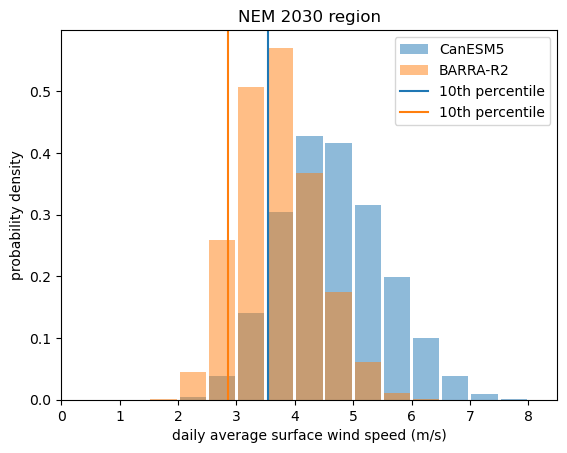

In [15]:
bins = np.arange(0, 9.5, 0.5)
plt.hist(sfcWind_model_data, bins=bins, density=True, rwidth=0.9, label='CanESM5', color='tab:blue', alpha=0.5)
plt.hist(sfcWind_obs_data, bins=bins, density=True, rwidth=0.9, label='BARRA-R2', color='tab:orange', alpha=0.5)
plt.axvline(pctl10_model, color='tab:blue', label='10th percentile')
plt.axvline(pctl10_obs, color='tab:orange', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('probability density')
plt.title('NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()

## Calculate annual maximum wind drought duration (WDDx)

In [16]:
wddx_model = utils.calc_wddx_model(ds_model, pctl10_model)

In [17]:
wddx_model

<xarray.Dataset> Size: 274kB
Dimensions:       (ensemble: 20, init_date: 57, lead_time: 10)
Coordinates:
  * ensemble      (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * init_date     (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 ...
    time          (ensemble, init_date, lead_time) object 91kB 1961-01-01 00:...
  * lead_time     (lead_time) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    event_length  (ensemble, init_date, lead_time) float64 91kB 3.0 2.0 ... 3.0
    event_start   (ensemble, init_date, lead_time) object 91kB 1961-06-28 12:...

In [18]:
wddx_model_df = wddx_model.stack({'sample': ['ensemble', 'init_date', 'lead_time']}).to_dataframe().reset_index(drop=True)
top_events = wddx_model_df.sort_values(['event_length'], ascending=False).head(n=5)
top_events

,event_length,event_start,time,ensemble,init_date,lead_time
8952,15.0,2003-05-10 12:00:00,2003-01-01 00:00:00,15,2001-05-01 00:00:00,3
9162,12.0,1967-05-12 12:00:00,1967-01-01 00:00:00,16,1965-05-01 00:00:00,3
3088,12.0,1992-05-30 12:00:00,1992-01-01 00:00:00,5,1984-05-01 00:00:00,9
6227,12.0,2020-07-01 12:00:00,2020-01-01 00:00:00,10,2013-05-01 00:00:00,8
7504,11.0,1974-07-13 12:00:00,1974-01-01 00:00:00,13,1970-05-01 00:00:00,5


In [19]:
utils.find_dcpp_data(top_events, 'CanESM5')

15.0 day event starting 2003-05-10: initialisation year 2000, ensemble member r16i1p2f1
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s2000-r16i1p2f1/day/pr
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s2000-r16i1p2f1/day/sfcWind
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s2000-r16i1p2f1/day/psl
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s2000-r16i1p2f1/day/tasmax
12.0 day event starting 1967-05-12: initialisation year 1964, ensemble member r17i1p2f1
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1964-r17i1p2f1/day/pr
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1964-r17i1p2f1/day/sfcWind
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1964-r17i1p2f1/day/psl
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1964-r17i1p2f1/day/tasmax
12.0 day event starting 1992-05-30: initialisation year 1983, ensemble member r6i1p2f1
/g/data/oi10/replicas/CMIP6/DCPP/CCCm

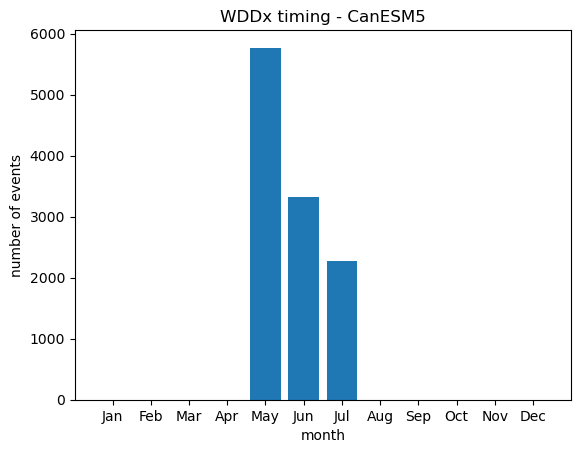

In [20]:
utils.plot_timing(wddx_model['event_start'], 'CanESM5')

In [21]:
wddx_obs = utils.calc_wddx_obs(ds_obs, pctl10_obs)

In [22]:
wddx_obs

<xarray.Dataset> Size: 1kB
Dimensions:       (time: 46)
Coordinates:
  * time          (time) datetime64[ns] 368B 1980-01-01 ... 2025-01-01
Data variables:
    event_length  (time) float64 368B 2.0 1.0 3.0 1.0 3.0 ... 3.0 2.0 2.0 3.0
    event_start   (time) datetime64[ns] 368B 1980-05-30T12:00:00 ... 2025-05-...

In [23]:
years = wddx_obs['event_start'].dt.year.values
wddx_obs_df = pd.DataFrame(index=years)
wddx_obs_df['WDDx'] = wddx_obs['event_length'].values
wddx_obs_df['start_date'] = wddx_obs['event_start'].dt.strftime('%Y-%m-%d')
wddx_obs_df.sort_values(['WDDx'], ascending=False).head(n=5)

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14


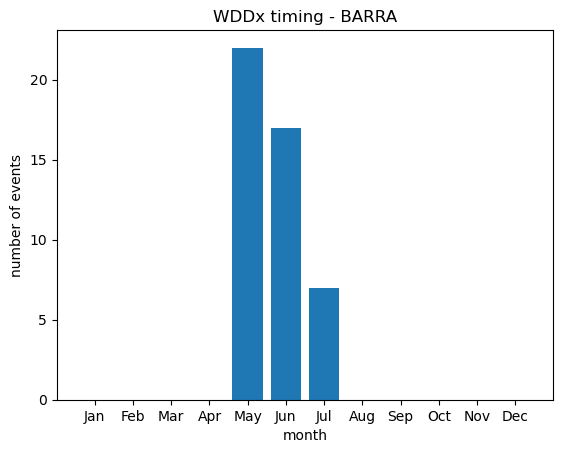

In [24]:
plot_timing(wddx_obs['event_start'], 'BARRA')

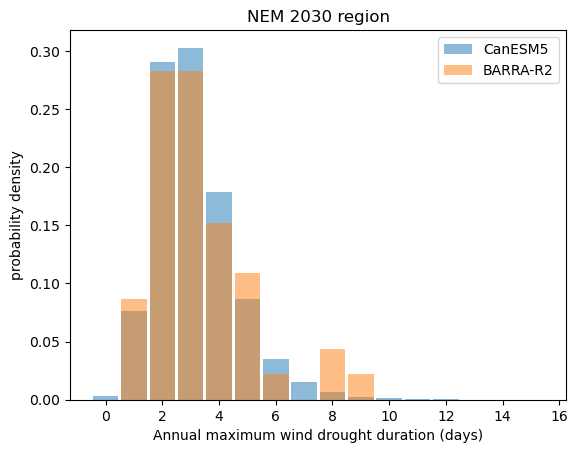

In [27]:
bins = np.arange(-0.5, 16.5, 1)
plt.hist(
    wddx_model['event_length'].values.flatten(),
    bins=bins,
    density=True,
    rwidth=0.9,
    label='CanESM5',
    color='tab:blue',
    alpha=0.5
)
plt.hist(
    wddx_obs['event_length'].values,
    bins=bins,
    density=True,
    rwidth=0.9,
    label='BARRA-R2',
    color='tab:orange',
    alpha=0.5
)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('probability density')
plt.title('NEM 2030 region')
plt.legend()
plt.show()

In [28]:
np.nanmax(wddx_model['event_length'].values)

np.float64(15.0)

In [29]:
np.max(wddx_obs['event_length'].values)

np.float64(9.0)

## Fidelity tests

#### Similarity test

We're looking for a KS-test p-value > 0.05. That means that the null hypothesis (i.e. that the two samples are from the same population) cannot be rejected. In other words, it means that the model and observational WDDx data are statistically similar.

In [30]:
ds_similarity = similarity.similarity_tests(
    wddx_model['event_length'],
    wddx_obs['event_length'],
)

In [31]:
ds_similarity['ks_pval'].values

array(0.9985495, dtype=float32)

#### Independence test

If you are interested in calculating the likelihood of a particular WDDx value, you need to make sure your samples are indepdent. 

To identify the lead time from which the ensemble members can be considered inpedendent, we use a permutation test to determine whether the correlation between ensemble members at a given lead time is sufficiently close to zero. For example, if the first lead time for which the correlation value falls between the dashed lines in the image below was 2, then we would drop lead time one from the analysis and calculate likelihoods using lead time 2 onwards.

In [32]:
ds_indep = independence.run_tests(
    wddx_model['event_length'],
    confidence_interval=0.95,
    n_resamples=1000
)

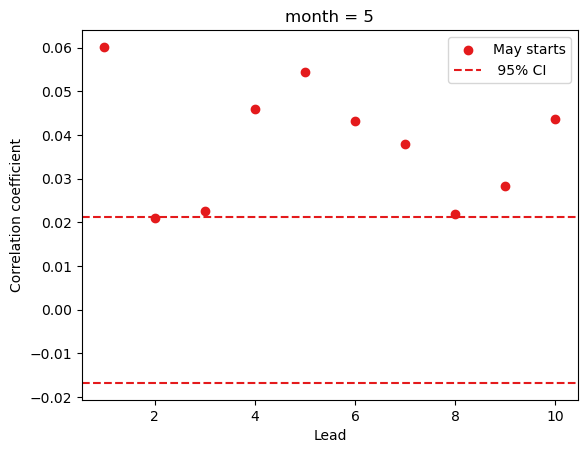

In [33]:
independence.point_plot(ds_indep)

#### Stability

Stability testing gives an indication of any trend or drift in the model data.

Unfortunately the distribution plots look a bit lumpy for categorical data like WDDx as (it's better for continuous data), but the return periods are smooth.

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


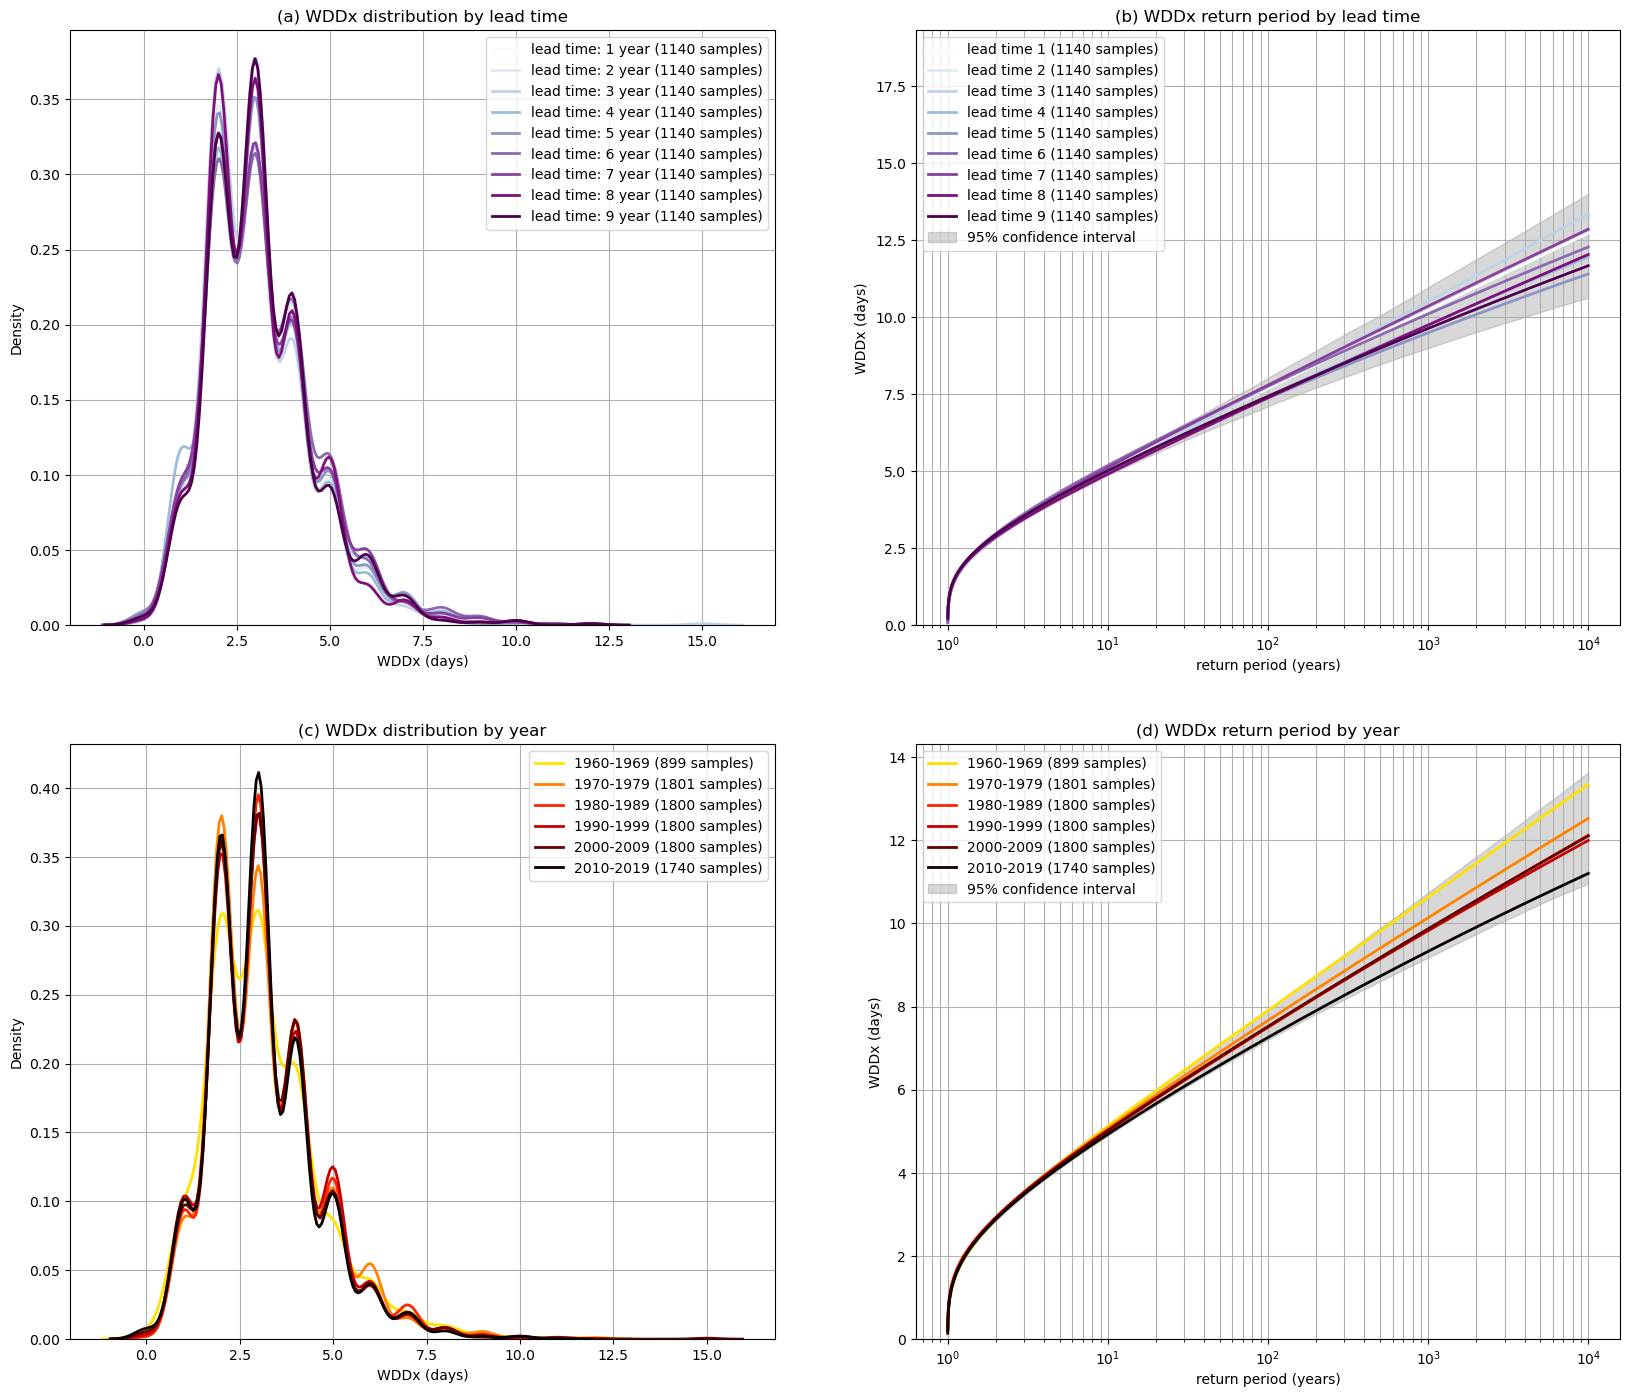

In [27]:
stability.create_plot(
    wddx_model['event_length'],
    'WDDx',
    [1960, 1970, 1980, 1990, 2000, 2010],
    return_method='gev',
    units='WDDx (days)',
    uncertainty=True,
)   